In [96]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize
from ITIS_Model_funcs import get_nominal_param, ITIS

In [97]:
##CURRENTLY POST INJECTION!! CHANGE IC IF DESIRED
def OLS_res(param_in,y_data,t_data,param_ids,output_ids,param_fix,IC):
    # First, we may only want to update certain parameters. This will be defined in param_ids, which should include
    # the indices for which parameters are updated. Param_fix will have the "fixed" values
    param_eval = param_fix
    param_eval[param_ids] = param_in
    ##Define time spaces
    tstart = 0
    t_end =24*8
    dt = .05
    tspace = np.arange(tstart,t_end,dt) # The time frame to solve the model to reach steady state (before we grab any output)
    tfinal = np.arange(0,24+dt,dt)

    ##Solve the model at nominal values
    ode_options = {'rtol': 1e-6} # sets the numerical accuracy of the ODE solver (i.e., how fine of a time step do we need)
    ODE_sol = odeint(ITIS, IC, tspace, args = (param_eval,), **ode_options)

    # MJC - this is where we can specify that the infection begins during this final time point
    IC_2    = ODE_sol[-1,:]
    IC_2[0] = 2.0
    # Resolve model only over 24 hours at subsampled time points. This will be used as our data
    ODE_sol = odeint(ITIS, IC_2, tfinal, args = (param_eval,), **ode_options)

    # In a similar way, the data may be only a subset of the observations. We will assume that
    # we have the same number of time points for now, but can modify this as well
    model_output = np.zeros((len(t_data),len(output_ids)))

    for i, time in enumerate(t_data):
        t_index = np.where(tspace==time) #Grabs the index correpsonding to where we have data
        for j, mod_out in enumerate(output_ids): #Loop over which outputs we want to compare to data
            print(ODE_sol[t_index, mod_out][0])
            model_output[i,j] = ODE_sol[t_index,mod_out][0][0]

    # Now, we have model outputs at the time points and recorded states. We can construct the residual and then the sum of squares
    # in the future, we can look at applying weights to the data that correspond to measurement noise
    # Here we just scale by the data
    # MJC - Since we pass in the data and then take the mean here, we don't need to do it at the beginning
    residual = (y_data - model_output)/np.mean(y_data,axis=0)

    return residual.flatten()

In [98]:
paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

In [99]:
param_log,IC = get_nominal_param()

##Define time spaces
tstart = 0
t_end =24*8
dt = .05
tspace = np.arange(tstart,t_end,dt)
tfinal = np.arange(0,24+dt,dt)

##Solve the model at nominal values
ode_options = {'rtol': 1e-6}
ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


#t_data = np.linspace(0,24,24+1) # time points every hour
t_data = np.linspace(0,24,12+1) # less data, every 30 minutes

0.0
13.617199996490431
15.503579663885665
1.4455460569360732
175.0598213566352
73.50616935679821
84.35214348009619
23.17384848467102
59.67539119906816
126.32770729033108
65.61110032512487
21.973808179365882
32.04818039343376
216.4326268400148
31.45157971798383
5.679587070211578
21.85277013291551
336.2539054469078
72.14249113257415
23.12904434995322
15.455254364258444
413.604147521271
69.3831166925238
7.132427454249862
12.00712201919632
485.5804958474653
44.60590275954832
10.493221750095335
9.84089326086926
480.95350620844147
63.83018374455452
7.661280621227842
8.444901744848893
468.311464118964
26.083943920334516
3.542192622264032
7.514007176414233
418.4938468905756
34.58458762523724
3.199747183544204
6.8557433329046535
363.2666857087303
19.78517453461211
1.3386489654359703
6.366287404404584
305.03649659325055
22.65595898279015
1.8984694690428563
5.967279321312819
249.46722465805144
26.870783896731805
1.722406099553685


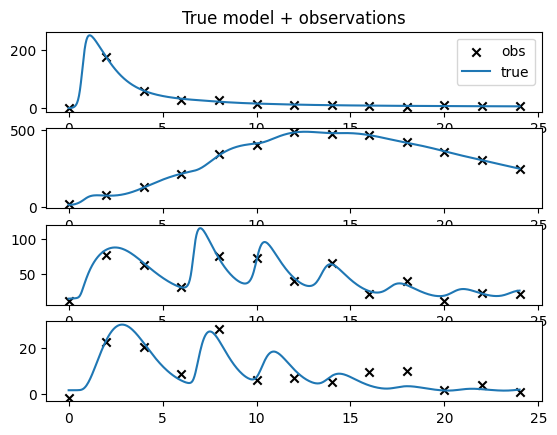

In [100]:
#Generate data
#output_ids = [6, 7] # Neuroendocrine = ACTH + Cort
#output_ids = [3, 6, 7] # TNF + ACTH + Cort
output_ids = [3,4,6,7] #TNF + IL10 + ACTH + Cort

# Define data
nt = len(t_data)
y_data = np.zeros((len(t_data),len(output_ids)))
# Here, we can add Gaussian, iid noise to the observations [REMOVE NOISE?]
for i, time in enumerate(t_data):
    index = np.where(tspace==time)
    for j,out_id in enumerate(output_ids):
        # This was causing an issue - it gave back a vector of 1s
        print(true_sol[index,out_id][0][0])
        y_data[i,j] = true_sol[index,out_id][0][0]


# If you want to add noise, add it here
y_data = y_data+ np.random.normal(0,4,(nt,len(output_ids)))

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k',label='obs')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true')
plt.title('True model + observations')
plt.legend()
#
plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[1]])

plt.subplot(4,1,3)
plt.scatter(t_data,y_data[:,2],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[2]])

plt.subplot(4,1,4)
plt.scatter(t_data,y_data[:,3],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[3]])

plt.show()


In [101]:
paramtitles.index('h10')

23

In [ ]:
# Define which parameters will be updated

##MOST SENSITIVE FOR ACTH + CORT
#param_ids = [33,12,36,32,7,34,31,15,8,9]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A
#param_ids = [33,12,36,32,7,34,31,15,8,9,16,14,28,26,1]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A + 1L10
param_ids = [33,12,36,32,7,34,31,15,8,9,16,14,28,26,1,21,22]

# To make the problem interesting, let's perturb our initial guess of these parameters by 1% [SHOULD WE DO THIS?]
param_in = np.log(np.exp(param_log[param_ids])*np.random.normal(1,0.1,(1,len(param_ids))).flatten())
# print(np.exp(param_log[param_ids]),np.exp(param_in))

# We may also want to constrain the parameters so they do not take on values in "unphysiological" regions
# Define upper bound UB and lower bound LB; remember we are on a log scale!

# MJC - make these bounds based on the parameter values
UB = np.log(np.exp(param_log[param_ids])*10)
LB =  np.log(np.exp(param_log[param_ids])*0.001)
print(UB,param_in,LB)


param_all = param_log


# Now, we set up a minimization problem
least_sq_sol = least_squares(OLS_res,param_in,args=(y_data,t_data,param_ids,output_ids,param_all,IC),
                             bounds=(LB,UB),verbose=2,xtol=1e-14,diff_step=1e-4)

print("initial guess",np.exp(param_in))
print("optimal solution",np.exp(least_sq_sol.x))
print("true solution",np.exp(param_log[param_ids]))
print("objective function value",least_sq_sol.cost) ##This thing




[ -1.83258146   0.46310489  -1.32425897   6.68461173 -17.98500979
  -5.45987206   7.02108396   9.64827267   1.60943791   8.51719319
  -1.22758267  12.78026736  -1.13943428  23.58877552  20.02923827
   1.33500107   6.89701784] [ -4.18329478  -1.96752587  -3.71761277   4.47528176 -20.21668793
  -7.57156425   4.68582318   7.23609923  -0.61507303   6.32845847
  -3.59978178  10.46415609  -3.2739923   21.19294856  17.7410978
  -1.01412258   4.58220645] [-11.04292184  -8.74723548 -10.53459934  -2.52572864 -27.19535017
 -14.67021243  -2.18925641   0.4379323   -7.60090246  -0.69314718
 -10.43792304   3.56992698 -10.34977466  14.37843515  10.8188979
  -7.87533931  -2.31332253]
[0.]
[39.91293166]
[9.6488693]
[1.67426764]
[21.33449102]
[76.54835678]
[28.82831566]
[4.45458519]
[37.71162908]
[112.45715415]
[24.4982807]
[2.83993557]
[29.19635243]
[158.16997027]
[49.00757318]
[10.84306896]
[21.47712231]
[211.17241216]
[63.41723845]
[10.81881171]
[16.18396261]
[277.02065007]
[35.89050103]
[9.12937753]


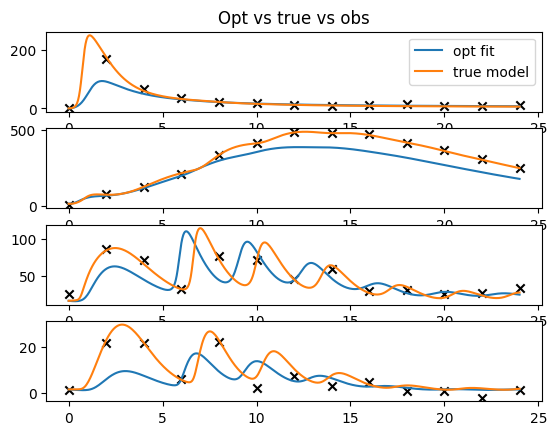

In [92]:
# MJC - plotting to look at solution
param_opt = param_log
param_opt[param_ids] = least_sq_sol.x
opt_model = odeint(ITIS, IC_2, tfinal, args = (param_opt,), **ode_options)

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[0]],label='opt fit')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true model')
plt.title('Opt vs true vs obs')
plt.legend()


plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[1]])
plt.plot(tfinal,true_sol[:,output_ids[1]])

plt.subplot(4,1,3)
plt.scatter(t_data,y_data[:,2],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[2]])
plt.plot(tfinal,true_sol[:,output_ids[2]])

plt.subplot(4,1,4)
plt.scatter(t_data,y_data[:,3],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[3]])
plt.plot(tfinal,true_sol[:,output_ids[3]])

plt.show()

In [93]:
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

Sensitivity_Mat = np.zeros((n_param, len(t_data) * n_states))  ##Initialize shape of sensitivity matrix.
for i in range(n_param):  #calculate the relative sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h ##    [HOW EXACTLY SHOULD I BE PERTURBING MY PARAM?]
        ##THIS THING NEXT DO THIS!!!
        Sensitivity_Mat[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_all, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_all, IC)))

twonorms = np.zeros(n_param)

for i in range(n_param):
        twonorms[i] = np.power(sum(np.power(Sensitivity_Mat[i, :], 2)), 1 / 2)


[0.]
[12.37579224]
[13.82400364]
[1.26628384]
[169.48176555]
[86.45725009]
[95.84576576]
[21.9155434]
[68.00275294]
[99.8612259]
[70.98096993]
[21.95092776]
[34.60158537]
[204.68819235]
[29.71475604]
[5.2427269]
[22.55164246]
[332.42859174]
[79.17045605]
[20.52245828]
[16.26543832]
[424.97152666]
[59.0829516]
[5.3352712]
[12.87262298]
[479.02954186]
[47.94324213]
[9.06619809]
[10.76623422]
[483.37347194]
[62.0939302]
[5.11601403]
[9.39729439]
[465.74609524]
[29.18413501]
[3.15730451]
[8.45287847]
[423.20773547]
[34.50138625]
[2.23075934]
[7.76783187]
[370.83156905]
[22.5304344]
[1.25762503]
[7.24172107]
[313.77154067]
[24.99421238]
[1.47141209]
[6.81026736]
[257.97555626]
[26.38193286]
[1.31396636]
[0.]
[12.37579224]
[13.82400364]
[1.26628384]
[169.48175]
[86.45735755]
[95.8457659]
[21.91554195]
[68.00263354]
[99.86136658]
[70.98104374]
[21.95101482]
[34.60153406]
[204.68867789]
[29.71469407]
[5.2427317]
[22.55161443]
[332.42946355]
[79.17081807]
[20.52254464]
[16.26541603]
[424.972604

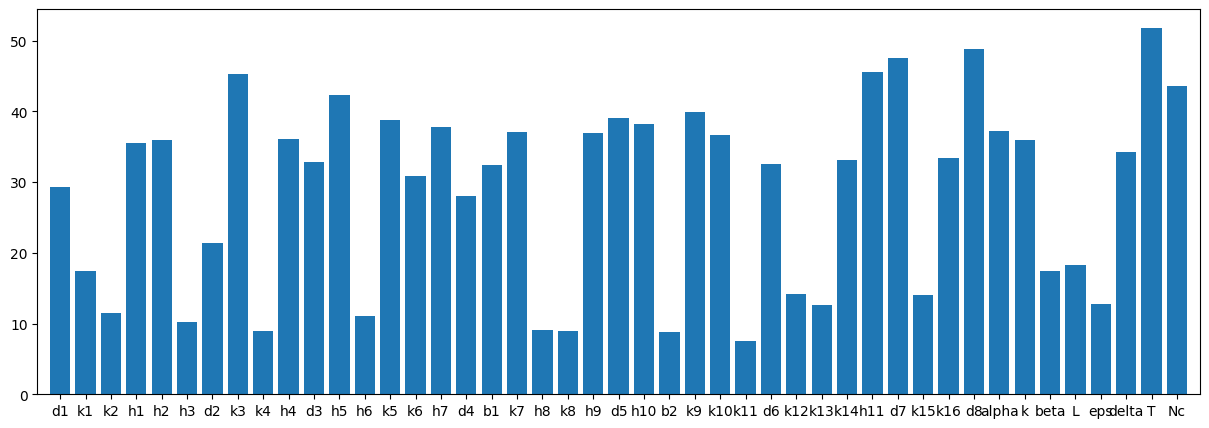

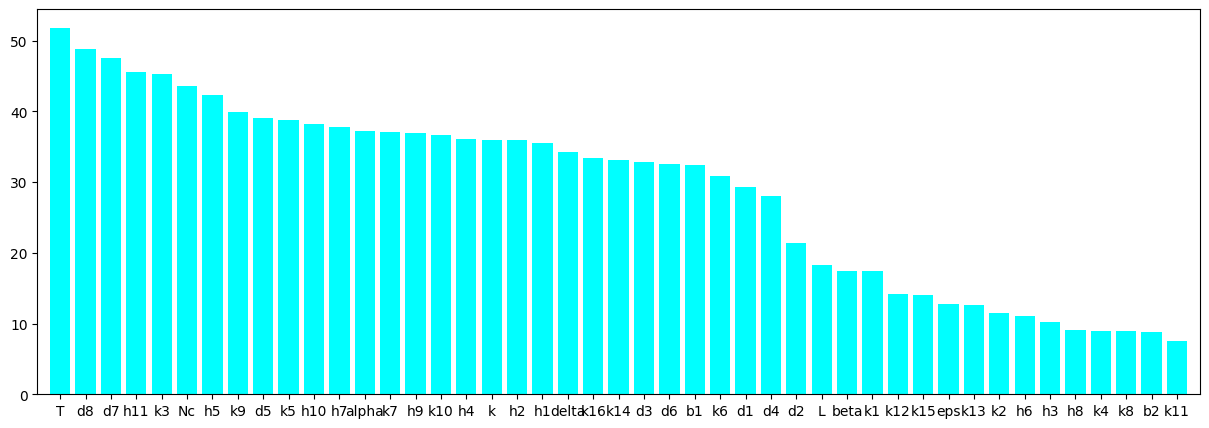

In [94]:
#PLOTTING
paramtitles = ['d1',
               'k1', 'k2', 'h1', 'h2', 'h3', 'd2',
               'k3', 'k4', 'h4', 'd3',
               'h5', 'h6', 'k5', 'k6', 'h7', 'd4',
               'b1', 'k7', 'h8', 'k8', 'h9', 'd5', 'h10',
               'b2', 'k9', 'k10', 'k11', 'd6',
               'k12', 'k13', 'k14', 'h11', 'd7',
               'k15', 'k16', 'd8',
               'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

statetitles = ["Endotoxin", "Phagocytes", "TGF-B", "TNF-a", "IL-10", "CRH", "ACTH", "Cortisol"]
statetitles_Short = ['endo', 'phag', 'TGFB', 'TNF', 'IL10', 'CRH', 'ACTH', 'cort']

fig, ax = plt.subplots(figsize = (15,5))
ax.bar(paramtitles,twonorms)
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

##Plot in descending order
data = sorted(zip(paramtitles, twonorms), key=lambda v: v[1], reverse = True)

plt.figure(figsize=(15, 5))
for (i, c) in data:  # unpack and plot each tuple in sorted order
    bars = plt.bar(i, c, align='center', color = 'cyan')
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

plt.show()

In [95]:
##CURRENT CONCERNS
import pickle

# all_results = {
#     'output_ids': output_ids,
#     'param_ids' : param_ids,
#     'param_in' : param_in,
#     'twonorms' : twonorms,
#     't_data' : t_data,
#     'y_data' : y_data,
#     'opt_model' : opt_model,
#     'true_sol' : true_sol,
#     'param_opt' : param_opt,
#     'optimal_solution' :np.exp(least_sq_sol.x),
#     'objvalue' : least_sq_sol.cost
# }
#
# with open('ResAnalysis32.pkl', 'wb') as f:
#     pickle.dump(all_results, f)
